# Functions

In [48]:
import matplotlib.pyplot as plt
import numpy as np

def plot_bev_with_boxes(pointcloud, pred_boxes, gt_boxes):
    """
    Plot BEV view with predicted and ground truth bounding boxes.
    
    Args:
        - pointcloud: numpy array of shape (N, 4), first 3 columns are x,y,z; only x,y used here
        - pred_boxes: numpy array of shape (M, 8, 3), predicted boxes, each box has 8 corner points
        - gt_boxes: numpy array of shape (K, 8, 3), ground truth boxes, each box has 8 corner points
    """
    plt.figure(figsize=(5, 5))
    
    # Plot point cloud: take first two columns (x, y)
    plt.scatter(pointcloud[:, 0], pointcloud[:, 1], s=0.5, c='gray', label="Point Cloud")
    
    # Plot predicted bounding boxes (red)
    label_added = False
    for box in pred_boxes:
        # Assume first 4 points are bottom corners
        corners = box[:4, :2]
        # Add first corner again to close the boundary
        corners = np.vstack([corners, corners[0]])
        if not label_added:
            plt.plot(corners[:, 0], corners[:, 1], 'r-', linewidth=2, label="Predicted Box")
            label_added = True
        else:
            plt.plot(corners[:, 0], corners[:, 1], 'r-', linewidth=2)
    
    # Plot ground truth bounding boxes (green)  
    label_added = False
    for box in gt_boxes:
        corners = box[:4, :2]
        corners = np.vstack([corners, corners[0]])
        if not label_added:
            plt.plot(corners[:, 0], corners[:, 1], 'g-', linewidth=2, label="GT Box")
            label_added = True
        else:
            plt.plot(corners[:, 0], corners[:, 1], 'g-', linewidth=2)
    
    plt.xlabel("X")
    plt.ylabel("Y") 
    plt.title("BEV: Predicted vs Ground Truth Bounding Boxes")
    plt.axis("equal")
    plt.legend()
    plt.grid(True)
    plt.show()


# Pipeline

In [8]:
import numpy as np
import os

In [50]:
i = '0000'
# base_path = '/home/labeling/repos/V2V4Real/pretrained/CoBEVT_compression'
# npy_folder = 'npy'
base_path = '/home/labeling/repos/OpenCOOD/pretrained/CoBEVT_compression'
npy_folder = 'npy'

gt_filename = f'{i}_gt.npy_test.npy'
pcd_filename = f'{i}_pcd.npy'
pred_filename = f'{i}_pred.npy'

gt = np.load(os.path.join(base_path, npy_folder, gt_filename))
pcd = np.load(os.path.join(base_path, npy_folder, pcd_filename))
pred = np.load(os.path.join(base_path, npy_folder, pred_filename))

In [44]:
print(gt.shape)
print(pred.shape)
print(pcd.shape)

(11, 8, 3)
(0,)
(7749, 4)


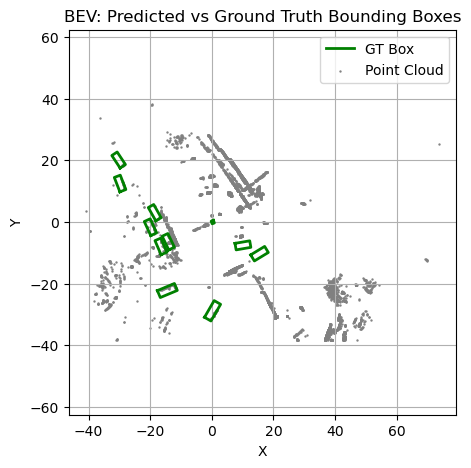

In [51]:
plot_bev_with_boxes(pcd, pred, gt)

# Our dataset checking

In [26]:
import yaml
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle
import open3d as o3d
import os
from opencood.hypes_yaml.yaml_utils import load_yaml
from opencood.utils.transformation_utils import x_to_world, x1_to_x2

def plot_bev_with_yaml_boxes(pcd_file, yaml_file):
    """Plot point cloud and bounding boxes in vehicle coordinate system"""
    # Load point cloud
    pcd = o3d.io.read_point_cloud(pcd_file)
    points = np.asarray(pcd.points)
    
    # Load yaml file
    data = load_yaml(yaml_file)
    
    # Get lidar pose
    lidar_pose = np.array(data['lidar_pose'])
    lidar_pose = lidar_matrix_to_pose(lidar_pose)
    print(f"lidar_pose: {lidar_pose}")
    
    # Create figure
    fig, ax = plt.subplots(figsize=(8, 8))
    
    # Plot point cloud BEV view (using only x and y coordinates)
    ax.scatter(points[:, 0], points[:, 1], s=0.1, c='blue', alpha=0.5)
    
    # Plot vehicle bounding boxes
    vehicles = data.get('vehicles', {})
    for vehicle_id, vehicle_info in vehicles.items():
        print(vehicle_id)
        # Get vehicle position and dimensions
        location = vehicle_info['location']
        extent = vehicle_info['extent']
        angle = vehicle_info['angle']  # Use the second angle (rotation around z-axis)
        
        # Create vehicle pose in global coordinate system
        vehicle_pose = [location[0], location[1], location[2], angle[0], angle[1], angle[2]]
        print(f"vehicle_pose: {vehicle_pose}")
        # Transform from object to lidar coordinate system
        object2lidar = x1_to_x2(vehicle_pose, lidar_pose)
        print(f"object2lidar: {object2lidar}")

        # shape (3, 8)
        bbx = create_bbx(extent).T
        # bounding box under ego coordinate shape (4, 8)
        bbx = np.r_[bbx, [np.ones(bbx.shape[1])]]

        # project the 8 corners to world coordinate
        bbx_lidar = np.dot(object2lidar, bbx).T
        bbx_lidar = np.expand_dims(bbx_lidar[:, :3], 0)[0]

        # Draw the bounding box
        # Bottom four corners (first four points)
        bottom_corners = bbx_lidar[:4, :2]  # Only take x and y coordinates for BEV view
        
        # Connect the bottom four corners to form a closed polygon
        # Connect points in order: 0->1->2->3->0
        for i in range(4):
            j = (i + 1) % 4
            ax.plot([bottom_corners[i, 0], bottom_corners[j, 0]],
                    [bottom_corners[i, 1], bottom_corners[j, 1]],
                    'r-', linewidth=2)
        
        # Add vehicle ID label
        center_x = np.mean(bottom_corners[:, 0])
        center_y = np.mean(bottom_corners[:, 1])
        ax.text(center_x, center_y, f"{vehicle_id}", 
                color='black', fontsize=8, ha='center', va='center')
        print(f"vehicle_center: {[center_x, center_y]}")
        print("--------------------------------")
    
    # Limit view to the majority of points by using percentiles
    x_min, x_max = np.percentile(points[:, 0], [0.1, 99.9])
    y_min, y_max = np.percentile(points[:, 1], [0.1, 99.9])
    
    # Add some margin
    margin = 5  # meters
    ax.set_xlim(x_min - margin, x_max + margin)
    ax.set_ylim(y_min - margin, y_max + margin)
    
    # Set axis labels
    ax.set_xlabel('X (m)')
    ax.set_ylabel('Y (m)')
    ax.set_title('Point Cloud BEV View with Vehicle Bounding Boxes')
    ax.set_aspect('equal')  # Keep x and y axis scales equal




def create_bbx(extent):
    """
    Create bounding box with 8 corners under obstacle vehicle reference.

    Parameters
    ----------
    extent : list
        Width, height, length of the bbx.

    Returns
    -------
    bbx : np.array
        The bounding box with 8 corners, shape: (8, 3)
    """

    bbx = np.array([[extent[0], -extent[1], -extent[2]],
                    [extent[0], extent[1], -extent[2]],
                    [-extent[0], extent[1], -extent[2]],
                    [-extent[0], -extent[1], -extent[2]],
                    [extent[0], -extent[1], extent[2]],
                    [extent[0], extent[1], extent[2]],
                    [-extent[0], extent[1], extent[2]],
                    [-extent[0], -extent[1], extent[2]]])

    return bbx

def lidar_matrix_to_pose(matrix):
    """
    Convert 4x4 transformation matrix to [x, y, z, roll, yaw, pitch]
    """
    if isinstance(matrix, list) and isinstance(matrix[0], list):
        matrix = np.array(matrix)
    x = matrix[0, 3]
    y = matrix[1, 3]
    z = matrix[2, 3]
    
    # Extract rotation angles from matrix
    pitch = np.arcsin(matrix[2, 0])
    yaw = np.arctan2(matrix[1, 0], matrix[0, 0])
    roll = np.arctan2(-matrix[2, 1], matrix[2, 2])
    
    return [x, y, z, np.degrees(roll), np.degrees(yaw), np.degrees(pitch)]

lidar_pose: [21.800890193423893, 4.569207865925094, 0.8318181392242534, 1.3356502259059815, -176.35535199581045, -0.8748018119541623]
30
vehicle_pose: [21.489860684922782, 12.252669877936482, -1.4384795422343726, -1.3271362034559253, -175.8017726428038, 0.8876663376341545]
object2lidar: [[ 0.99948026 -0.01037023 -0.0305233  -0.14334084]
 [ 0.00894096  0.99887384 -0.04659524 -7.63262859]
 [ 0.03097213  0.04629811  0.9984474  -2.45132894]
 [ 0.          0.          0.          1.        ]]
vehicle_center: [-0.113679230903867, -7.5873487801008865]
--------------------------------
31
vehicle_pose: [30.16364694208678, 4.8053509858487455, -1.4583153188629225, -1.4006662242614087, 179.1073070799082, 0.7663890941259539]
object2lidar: [[ 0.99645642  0.07837688 -0.0305233  -8.32491493]
 [-0.07974669  0.99572554 -0.04659524  0.35221043]
 [ 0.02674084  0.04886425  0.9984474  -2.40996151]
 [ 0.          0.          0.          1.        ]]
vehicle_center: [-8.294828210774803, 0.39813920198623887]
-

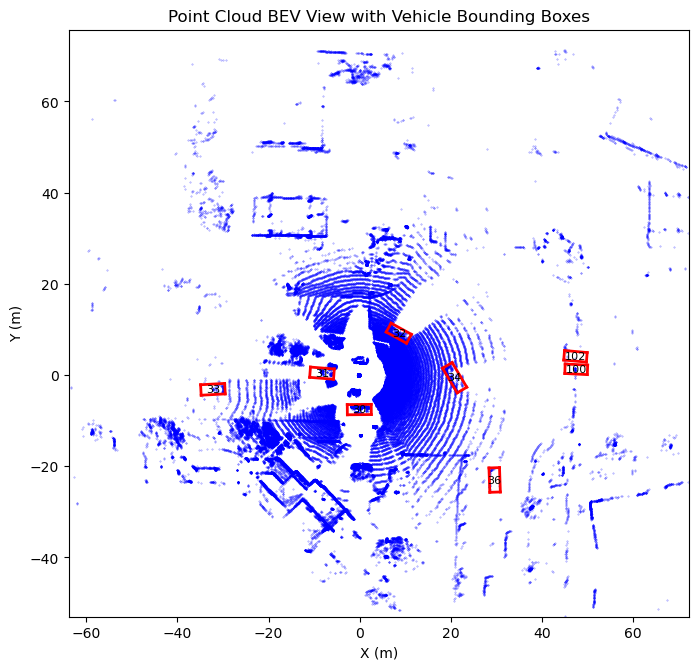

In [27]:
# Example usage
yaml_file = '/home/labeling/datasets/ours/img_83850/0/85380.yaml'
pcd_file = '/home/labeling/datasets/ours/img_83850/0/85380.pcd' # Assume pcd file is in the same directory as yaml file

# Check if files exist
if os.path.exists(yaml_file) and os.path.exists(pcd_file):
    plot_bev_with_yaml_boxes(pcd_file, yaml_file)
else:
    print(f"Files do not exist, please check paths: \nYAML: {yaml_file}\nPCD: {pcd_file}")